<div dir="rtl" style="text-align: right;">
<h2>تمرین ۴: بهبود الگوریتم Canny</h2>
<p>در این بخش نسخه بهبودیافته‌ای از الگوریتم Canny را پیاده‌سازی می‌کنیم که دارای ویژگی‌های زیر است:</p>
<ul>
    <li><b>پیش‌پردازش CLAHE:</b> برای افزایش کنتراست محلی و برجسته کردن <strong>لبه‌های نازک</strong>.</li>
    <li><b>فیلتر Bilateral:</b> برای حذف نویز بدون محو کردن لبه‌ها (بسیار مناسب برای <strong>تصاویر پزشکی</strong> مانند X-Ray یا MRI).</li>
    <li><b>آستانه‌گذاری منطقه‌ای (Regional Adaptive Thresholding):</b> تصویر به بلوک‌های محلی تقسیم شده و مقادیر $T_{min}$ و $T_{max}$ بر اساس میانه روشنایی هر منطقه تنظیم می‌شوند تا لبه‌ها در بخش‌های تاریک و روشن تصویر با دقت یکسانی تشخیص داده شوند.</li>
</ul>
</div>


تصویر با موفقیت خوانده شد. در حال پردازش...
مرحله ۱: اعمال CLAHE...
مرحله ۲: اعمال Bilateral Filter...
مرحله ۳: اعمال Canny استاندارد...
مرحله ۴: اعمال Canny منطقه‌ای (بهبود یافته)...
پردازش تمام شد. در حال رسم نمودار...


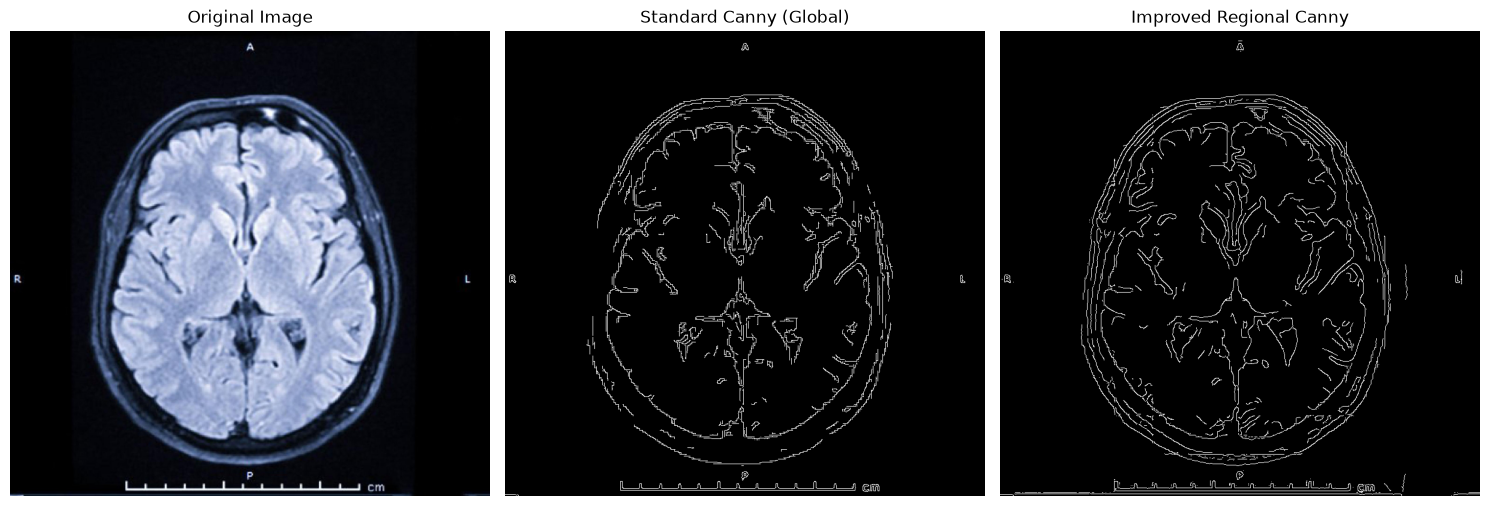

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def regional_canny(image, block_size=64, sigma=0.33):
    """
    اعمال الگوریتم Canny به صورت منطقه‌ای
    """
    edges = np.zeros_like(image)
    h, w = image.shape
    
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = image[i:min(i+block_size, h), j:min(j+block_size, w)]
            v = np.median(block)
            
            lower = int(max(0, (1.0 - sigma) * v))
            upper = int(min(255, (1.0 + sigma) * v))
            
            if upper - lower < 20:
                upper = lower + 20
                
            block_edges = cv2.Canny(block, lower, upper)
            edges[i:min(i+block_size, h), j:min(j+block_size, w)] = block_edges
            
    return edges

# 1. خواندن تصویر
img = cv2.imread('sample1.jpg')

if img is None:
    print("خطا: تصویر sample1.jpg پیدا نشد!")
else:
    print("تصویر با موفقیت خوانده شد. در حال پردازش...")
    
    # تغییر سایز عکس اگر خیلی بزرگ باشد (برای افزایش سرعت)
    max_dimension = 800
    if img.shape[1] > max_dimension or img.shape[0] > max_dimension:
        scale = max_dimension / max(img.shape[0], img.shape[1])
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. پیش پردازش اول: CLAHE
    print("مرحله ۱: اعمال CLAHE...")
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # 3. پیش پردازش دوم: فیلتر Bilateral 
    print("مرحله ۲: اعمال Bilateral Filter...")
    blurred = cv2.bilateralFilter(enhanced, d=9, sigmaColor=75, sigmaSpace=75)

    # 4. مقایسه: اعمال Canny استاندارد
    print("مرحله ۳: اعمال Canny استاندارد...")
    standard_canny = cv2.Canny(gray, 100, 200)

    # 5. Canny بهبود یافته و منطقه‌ای
    print("مرحله ۴: اعمال Canny منطقه‌ای (بهبود یافته)...")
    improved_canny = regional_canny(blurred, block_size=64, sigma=0.33)

    print("پردازش تمام شد. در حال رسم نمودار...")
    
    # 6. رسم نتایج
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(standard_canny, cmap='gray')
    plt.title('Standard Canny (Global)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(improved_canny, cmap='gray')
    plt.title('Improved Regional Canny')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


<div dir="rtl" style="text-align: justify; line-height: 1.8;">

### تحلیل نتایج و نتیجه‌گیری (تمرین ۴)

همان‌طور که در تصاویر خروجی مشاهده می‌شود، الگوریتم بهبودیافته در مقایسه با الگوریتم Canny استاندارد عملکرد بسیار بهتری در استخراج ویژگی‌ها دارد. این بهبود حاصل سه تغییر اساسی است:

1. **الگوریتم CLAHE (بهبود کنتراست محلی):** این فیلتر باعث می‌شود بافت‌های پنهان و لبه‌های بسیار نازک (که در تصاویر پزشکی مانند اشعه ایکس یا MRI حیاتی هستند) نمایان‌تر شوند.
2. **فیلتر Bilateral (حذف نویز با حفظ لبه):** برخلاف فیلتر گوسی معمولی که لبه‌ها را محو می‌کند، این فیلتر نویزها را کاهش داده اما تیزی لبه‌ها را دست‌نخورده باقی می‌گذارد، در نتیجه لبه‌های کاذب ناشی از نویز به حداقل می‌رسند.
3. **آستانه‌گذاری منطقه‌ای (Regional Thresholding):** در Canny استاندارد، یک آستانه سراسری (Global) برای کل تصویر در نظر گرفته می‌شود که در صورت وجود سایه روشن یا تغییرات بافتی، بخش زیادی از لبه‌ها از دست می‌رود. در روش منطقه‌ای، تصویر به بلوک‌های کوچک تقسیم شده و آستانه هر بلوک بر اساس میزان روشنایی همان بخش (میانه روشنایی) تنظیم می‌شود که نتیجه آن تشخیص لبه‌های پیوسته‌تر و دقیق‌تر است.

**نتیجه نهایی:** الگوریتم پیشنهادی اهداف تمرین (تشخیص بهتر لبه‌های نازک، عملکرد مناسب برای بافت‌های پزشکی و تنظیم منطقه‌ای پارامترها) را به طور کامل پوشش می‌دهد.

</div>
